<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/Project-3/SQL_1_Chinook_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [ ]:
# Install the sqlite package for Ubuntu
# Download the Chinook sqlite database


In [ ]:
import sqlite3 as db
import pandas as pd

In [ ]:
%%capture install_output
%%bash
apt-get update
apt-get install -y sqlite3
pip install sqlite-web

In [ ]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip

Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [ ]:
!rm -f chinook.db

In [ ]:
!unzip -u chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


In [ ]:
!ls -la

total 1180
drwxr-xr-x 1 root root   4096 May  8 03:08 .
drwxr-xr-x 1 root root   4096 May  8 03:04 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 May  8 03:08 chinook.zip
drwxr-xr-x 4 root root   4096 Apr 16 13:28 .config
drwxr-xr-x 1 root root   4096 Apr 16 13:28 sample_data


## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



I am interested in what fraction of tracks and albums fall into what catergories and how those fractions relate to sales.  I will pull information to explore these issues.  

## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


### Basic Queries


#### SELECT (with * and with column names)


In [ ]:
db_con = db.connect("chinook.db")

In [ ]:
query = '''
  select *
  from tracks
  limit 10
'''

tracks = pd.read_sql_query( query , db_con)
tracks

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,6,Put The Finger On You,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,7,Let's Get It Up,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,8,Inject The Venom,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,9,Snowballed,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,10,Evil Walks,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


In [ ]:
query = '''
  select *
  from albums
  limit 20
'''

albums = pd.read_sql_query( query , db_con)
albums

,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3
5,6,Jagged Little Pill,4
6,7,Facelift,5
7,8,Warner 25 Anos,6
8,9,Plays Metallica By Four Cellos,7
9,10,Audioslave,8


In [ ]:
query = '''
  select *
  from genres
  limit 20
'''

genres = pd.read_sql_query( query , db_con)
genres

,GenreId,Name
0,1,Rock
1,2,Jazz
2,3,Metal
3,4,Alternative & Punk
4,5,Rock And Roll
5,6,Blues
6,7,Latin
7,8,Reggae
8,9,Pop
9,10,Soundtrack


#### WHERE


In [ ]:
query = '''
  select *
  from tracks
  where GenreId = 1
  limit 20
'''
rock = pd.read_sql_query( query , db_con)
rock

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,6,Put The Finger On You,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,7,Let's Get It Up,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,8,Inject The Venom,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,9,Snowballed,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,10,Evil Walks,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


#### AND


In [ ]:
query = '''
  select *
  from tracks
  where GenreId = 1 AND MediaTypeId = 2
  limit 20
'''
rock2 = pd.read_sql_query( query , db_con)
rock

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,6,Put The Finger On You,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,7,Let's Get It Up,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,8,Inject The Venom,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,9,Snowballed,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,10,Evil Walks,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


#### OR


In [ ]:
query = '''
  select *
  from tracks
  where GenreId = 18 OR GenreId = 20
  limit 20
'''
scifi2 = pd.read_sql_query( query , db_con)
scifi2

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,2819,Battlestar Galactica: The Story So Far,226,3,18,None,2622250,490750393,1.99
1,2825,A Measure of Salvation,227,3,18,None,2563938,489715554,1.99
2,2826,Hero,227,3,18,None,2713755,506896959,1.99
3,2827,Unfinished Business,227,3,18,None,2622038,528499160,1.99
4,2828,The Passage,227,3,18,None,2623875,490375760,1.99
5,2829,The Eye of Jupiter,227,3,18,None,2618750,517909587,1.99
6,2830,Rapture,227,3,18,None,2624541,508406153,1.99
7,2831,Taking a Break from All Your Worries,227,3,18,None,2624207,492700163,1.99
8,2832,The Woman King,227,3,18,None,2626376,552893447,1.99
9,2833,A Day In the Life,227,3,18,None,2620245,462818231,1.99


#### LIKE (with % or _ wildcard)


In [ ]:
query = '''
  select *
  from albums
  where Title LIKE '%J%'
  limit 20
'''

albumsJ = pd.read_sql_query( query , db_con)
albumsJ

,AlbumId,Title,ArtistId
0,6,Jagged Little Pill,4
1,69,Djavan Ao Vivo - Vol. 02,80
2,70,Djavan Ao Vivo - Vol. 1,80
3,122,Jorge Ben Jor 25 Anos,46
4,123,Jota Quest-1995,96
5,156,...And Justice For All,50
6,179,Pearl Jam,118
7,201,Judas 0: B-Sides and Rarities,131
8,259,Radio Brasil (O Som da Jovem Vanguarda) - Sele...,36
9,307,"Adams, John: The Chairman Dances",242


#### BETWEEN


In [ ]:
query = '''
  select *
  from tracks
  where GenreId BETWEEN 3 AND 5
  limit 20
'''
music1 = pd.read_sql_query( query , db_con)
music1

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,77,Enter Sandman,9,1,3,Apocalyptica,221701,7286305,0.99
1,78,Master Of Puppets,9,1,3,Apocalyptica,436453,14375310,0.99
2,79,Harvester Of Sorrow,9,1,3,Apocalyptica,374543,12372536,0.99
3,80,The Unforgiven,9,1,3,Apocalyptica,322925,10422447,0.99
4,81,Sad But True,9,1,3,Apocalyptica,288208,9405526,0.99
5,82,Creeping Death,9,1,3,Apocalyptica,308035,10110980,0.99
6,83,Wherever I May Roam,9,1,3,Apocalyptica,369345,12033110,0.99
7,84,Welcome Home (Sanitarium),9,1,3,Apocalyptica,350197,11406431,0.99
8,131,Intro/ Low Down,14,1,3,None,323683,10642901,0.99
9,132,13 Years Of Grief,14,1,3,None,246987,8137421,0.99


#### LIMIT



In [ ]:
query = '''
  select *
  from tracks
  where GenreId BETWEEN 3 AND 5
  limit 50
'''
music1 = pd.read_sql_query( query , db_con)
music1

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,77,Enter Sandman,9,1,3,Apocalyptica,221701,7286305,0.99
1,78,Master Of Puppets,9,1,3,Apocalyptica,436453,14375310,0.99
2,79,Harvester Of Sorrow,9,1,3,Apocalyptica,374543,12372536,0.99
3,80,The Unforgiven,9,1,3,Apocalyptica,322925,10422447,0.99
4,81,Sad But True,9,1,3,Apocalyptica,288208,9405526,0.99
5,82,Creeping Death,9,1,3,Apocalyptica,308035,10110980,0.99
6,83,Wherever I May Roam,9,1,3,Apocalyptica,369345,12033110,0.99
7,84,Welcome Home (Sanitarium),9,1,3,Apocalyptica,350197,11406431,0.99
8,131,Intro/ Low Down,14,1,3,None,323683,10642901,0.99
9,132,13 Years Of Grief,14,1,3,None,246987,8137421,0.99


### Sorting and Grouping


#### ORDER BY


In [ ]:
query = '''
  select *
  from tracks
  ORDER BY Composer DESC
  limit 20
'''
music2 = pd.read_sql_query( query , db_con)
music2

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,817,Lick It Up,66,1,1,roger glover,240274,7792604,0.99
1,819,Talk About Love,66,1,1,roger glover,247823,8072171,0.99
2,820,Time To Kill,66,1,1,roger glover,351033,11354742,0.99
3,821,Ramshackle Man,66,1,1,roger glover,334445,10874679,0.99
4,822,A Twist In The Tail,66,1,1,roger glover,257462,8413103,0.99
5,824,Solitaire,66,1,1,roger glover,282226,9157021,0.99
6,825,One Man's Meat,66,1,1,roger glover,278804,9068960,0.99
7,1055,Loves Been Good To Me,83,1,12,rod mckuen,203964,6645365,0.99
8,1041,For Once In My Life,83,1,12,orlando murden/ronald miller,171154,5557537,0.99
9,1052,The Lady Is A Tramp,83,1,12,lorenz hart/richard rodgers,184111,5987372,0.99


#### DISTINCT


In [ ]:
query = '''
  select DISTINCT composer
  from tracks
  limit 20
'''
music3 = pd.read_sql_query( query , db_con)
music3

,Composer
0,"Angus Young, Malcolm Young, Brian Johnson"
1,None
2,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho..."
3,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D..."
4,Deaffy & R.A. Smith-Diesel
5,AC/DC
6,"Steven Tyler, Joe Perry, Jack Blades, Tommy Shaw"
7,"Steven Tyler, Joe Perry"
8,"Steven Tyler, Joe Perry, Jim Vallance, Holly K..."
9,"Steven Tyler, Joe Perry, Desmond Child"


In [ ]:
query = '''
  select DISTINCT Name
  from tracks
  WHERE Composer = 'AC/DC'
  limit 20
'''
music4 = pd.read_sql_query( query , db_con)
music4

,Name
0,Go Down
1,Dog Eat Dog
2,Let There Be Rock
3,Bad Boy Boogie
4,Problem Child
5,Overdose
6,Hell Ain't A Bad Place To Be
7,Whole Lotta Rosie


#### GROUP BY



In [ ]:
query = '''
  select composer, count (*)
  from tracks
  GROUP BY composer
  limit 20
'''
music5 = pd.read_sql_query( query , db_con)
music5

,Composer,count (*)
0,None,978
1,"A. F. Iommi, W. Ward, T. Butler, J. Osbourne",3
2,A. Jamal,1
3,A.Bouchard/J.Bouchard/S.Pearlman,1
4,A.Isbell/A.Jones/O.Redding,1
5,AC/DC,8
6,Aaron Copland,1
7,Aaron Goldberg,1
8,Ace Frehley,2
9,"Acyi Marques/Arlindo Bruz/Braço, Beto Sem/Zeca...",1


In [ ]:
query = '''
  select composer, count (*)
  from tracks
  GROUP BY composer ORDER BY count (*) DESC
  limit 20
'''
music6 = pd.read_sql_query( query , db_con)
music6

,Composer,count (*)
0,None,978
1,Steve Harris,80
2,U2,44
3,Jagger/Richards,35
4,Billy Corgan,31
5,Kurt Cobain,26
6,Bill Berry-Peter Buck-Mike Mills-Michael Stipe,25
7,The Tea Party,24
8,Miles Davis,23
9,Gilberto Gil,23


In [ ]:
query = '''
  select composer, count (*)
  from tracks
  GROUP BY composer
  HAVING count (*) > 1
  ORDER BY count (*) DESC
  limit 20
'''
music6 = pd.read_sql_query( query , db_con)
music6

,Composer,count (*)
0,None,978
1,Steve Harris,80
2,U2,44
3,Jagger/Richards,35
4,Billy Corgan,31
5,Kurt Cobain,26
6,Bill Berry-Peter Buck-Mike Mills-Michael Stipe,25
7,The Tea Party,24
8,Miles Davis,23
9,Gilberto Gil,23


### Aggregates


#### MAX


In [ ]:
%%script sqlite3 --column --header chinook.db
SELECT MAX(UnitPrice)
FROM Tracks
;


MAX(UnitPrice)
--------------
1.99          


#### MIN


In [ ]:
%%script sqlite3 --column --header chinook.db
SELECT MIN(UnitPrice)
FROM Tracks
;


MIN(UnitPrice)
--------------
0.99          


#### SUM


In [ ]:
%%script sqlite3 --column --header chinook.db
SELECT SUM(Milliseconds)
FROM Tracks
;

SUM(Milliseconds)
-----------------
1378778040       


#### AVG


In [ ]:
%%script sqlite3 --column --header chinook.db
SELECT AVG(Milliseconds)
FROM Tracks
;

AVG(Milliseconds)
-----------------
393599.212103911 


#### COUNT



In [ ]:
%%script sqlite3 --column --header chinook.db
SELECT count(ArtistId)
FROM artists
;

count(ArtistId)
---------------
275            


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [ ]:
query = '''
  select composer, count (*) AS num_tracks
  from tracks
  GROUP BY composer
  HAVING count (*) > 1
  ORDER BY count (*) DESC
'''
music7 = pd.read_sql_query( query , db_con)

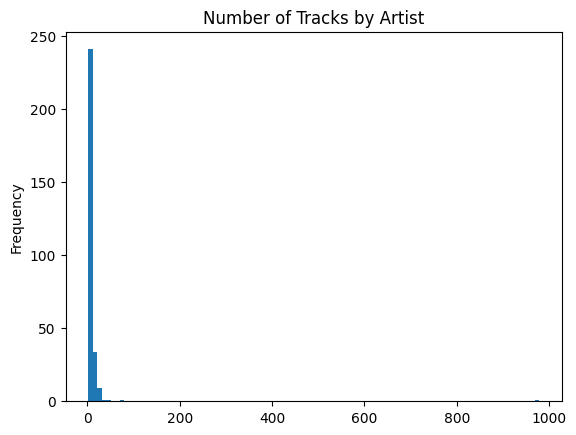

In [ ]:
import matplotlib.pyplot as plt
music7['num_tracks'].plot(kind='hist', bins = 100, title='Number of Tracks by Artist', ylabel='Frequency')
plt.show()

Note, there are a huge number of 'none' for composer, so I wanted to exclude this and other options similar (Unknown, Various).  I googled how.  The result was in SQL so I am tryng it with the pandas method

In [ ]:
query = '''
  SELECT composer, count(*) AS num_tracks
  FROM tracks
  WHERE composer IS NOT NULL
    AND composer NOT IN ('Various Artists', 'Unknown', 'None')
  GROUP BY composer
  HAVING count(*) > 1
  ORDER BY count(*) DESC
'''
music8 = pd.read_sql_query( query , db_con)

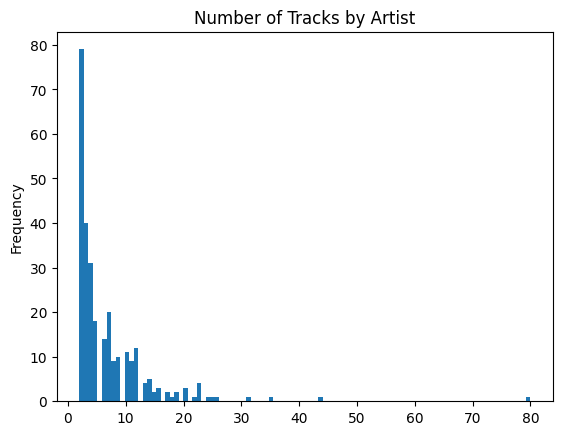

In [ ]:
music8['num_tracks'].plot(kind='hist', bins = 100, title='Number of Tracks by Artist', ylabel='Frequency')
plt.show()

In [ ]:
query = '''
  select GenreId, count (*) AS genre_tracks
  from tracks
  GROUP BY GenreId
  HAVING count (*) > 0
'''
music9 = pd.read_sql_query( query , db_con)
music9

,GenreId,genre_tracks
0,1,1297
1,2,130
2,3,374
3,4,332
4,5,12
5,6,81
6,7,579
7,8,58
8,9,48
9,10,43


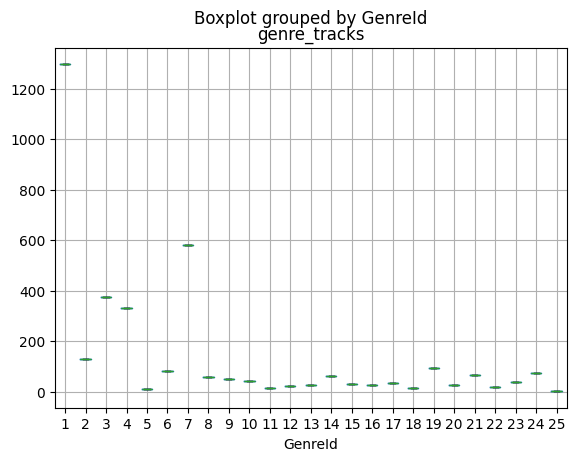

In [ ]:
music9.boxplot(column = 'genre_tracks', by='GenreId')
plt.show()

In [ ]:
import seaborn as sns

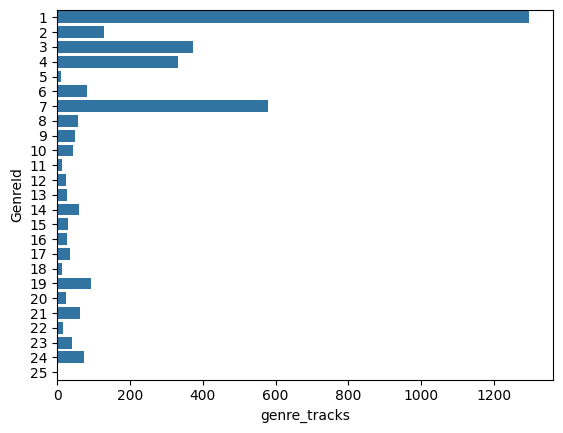

In [ ]:
sns.barplot(x="genre_tracks", y="GenreId", data=music9, orient='h');

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


In [ ]:
query = '''
  SELECT
    tracks.Name AS Song,
    genres.Name AS Genre,
    tracks.AlbumId,
    tracks.GenreId,
    tracks.UnitPrice,
    albums.AlbumId,
    albums.Title,
    albums.ArtistId

  FROM tracks
  INNER JOIN genres ON tracks.GenreId = genres.GenreId
  INNER JOIN albums ON tracks.AlbumId = albums.AlbumId
'''
genre = pd.read_sql_query( query , db_con)
genre

,Song,Genre,AlbumId,GenreId,UnitPrice,AlbumId,Title,ArtistId
0,For Those About To Rock (We Salute You),Rock,1,1,0.99,1,For Those About To Rock We Salute You,1
1,Balls to the Wall,Rock,2,1,0.99,2,Balls to the Wall,2
2,Fast As a Shark,Rock,3,1,0.99,3,Restless and Wild,2
3,Restless and Wild,Rock,3,1,0.99,3,Restless and Wild,2
4,Princess of the Dawn,Rock,3,1,0.99,3,Restless and Wild,2
...,...,...,...,...,...,...,...,...
3498,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,Classical,343,24,0.99,343,Respighi:Pines of Rome,226
3499,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",Classical,344,24,0.99,344,Schubert: The Late String Quartets & String Qu...,272
3500,"L'orfeo, Act 3, Sinfonia (Orchestra)",Classical,345,24,0.99,345,Monteverdi: L'Orfeo,273
3501,"Quintet for Horn, Violin, 2 Violas, and Cello ...",Classical,346,24,0.99,346,Mozart: Chamber Music,274


In [ ]:
query = '''
  select *
  from invoice_items
  limit 20
'''

invoice = pd.read_sql_query( query , db_con)
invoice

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1
3,4,2,8,0.99,1
4,5,2,10,0.99,1
5,6,2,12,0.99,1
6,7,3,16,0.99,1
7,8,3,20,0.99,1
8,9,3,24,0.99,1
9,10,3,28,0.99,1


In [ ]:
query = '''
  select count (InvoiceLineId)
  from invoice_items

'''

invoice2 = pd.read_sql_query( query , db_con)
invoice2

,count (InvoiceLineId)
0,2240


In [ ]:
query = '''
  SELECT
    invoice_items.*,
    tracks.Name AS Song,
    genres.Name AS Genre,
    tracks.AlbumId,
    tracks.GenreId

  FROM tracks
  LEFT OUTER JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
  LEFT OUTER JOIN genres ON tracks.GenreId = genres.GenreId
'''
invoice3 = pd.read_sql_query( query , db_con)
invoice3

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity,Song,Genre,AlbumId,GenreId
0,579.0,108.0,1.0,0.99,1.0,For Those About To Rock (We Salute You),Rock,1,1
1,1.0,1.0,2.0,0.99,1.0,Balls to the Wall,Rock,2,1
2,1154.0,214.0,2.0,0.99,1.0,Balls to the Wall,Rock,2,1
3,1728.0,319.0,3.0,0.99,1.0,Fast As a Shark,Rock,3,1
4,2.0,1.0,4.0,0.99,1.0,Restless and Wild,Rock,3,1
...,...,...,...,...,...,...,...,...,...
3754,578.0,108.0,3500.0,0.99,1.0,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",Classical,344,24
3755,1727.0,319.0,3500.0,0.99,1.0,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",Classical,344,24
3756,NaN,NaN,NaN,NaN,NaN,"L'orfeo, Act 3, Sinfonia (Orchestra)",Classical,345,24
3757,NaN,NaN,NaN,NaN,NaN,"Quintet for Horn, Violin, 2 Violas, and Cello ...",Classical,346,24


In [ ]:
invoice3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   InvoiceLineId  2240 non-null   float64
 1   InvoiceId      2240 non-null   float64
 2   TrackId        2240 non-null   float64
 3   UnitPrice      2240 non-null   float64
 4   Quantity       2240 non-null   float64
 5   Song           3759 non-null   object 
 6   Genre          3759 non-null   object 
 7   AlbumId        3759 non-null   int64  
 8   GenreId        3759 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 264.4+ KB


In [ ]:
invoice3['Quantity'].value_counts(dropna= False)

,count
Quantity,
1.0,2240
NaN,1519


In [ ]:
invoice3['UnitPrice'].value_counts(dropna= False)

,count
UnitPrice,
0.99,2129
NaN,1519
1.99,111


In [ ]:
query = '''
  SELECT
    genres.Name AS Genre,
    SUM (invoice_items.UnitPrice) AS Total_Sold,
    COUNT (invoice_items.TrackId) AS Tracks_Sold,
    COUNT (tracks.TrackId) AS Number_of_Tracks

  FROM tracks
  LEFT OUTER JOIN invoice_items ON tracks.TrackId = invoice_items.TrackId
  LEFT OUTER JOIN genres ON tracks.GenreId = genres.GenreId

  GROUP BY Genre
'''
invoice4 = pd.read_sql_query( query , db_con)
invoice4

,Genre,Total_Sold,Tracks_Sold,Number_of_Tracks
0,Alternative,13.86,14,40
1,Alternative & Punk,241.56,244,373
2,Blues,60.39,61,89
3,Bossa Nova,14.85,15,16
4,Classical,40.59,41,79
5,Comedy,17.91,9,18
6,Drama,57.71,29,66
7,Easy Listening,9.90,10,24
8,Electronica/Dance,11.88,12,31
9,Heavy Metal,11.88,12,28


Modified figure from instructions on Seaborn

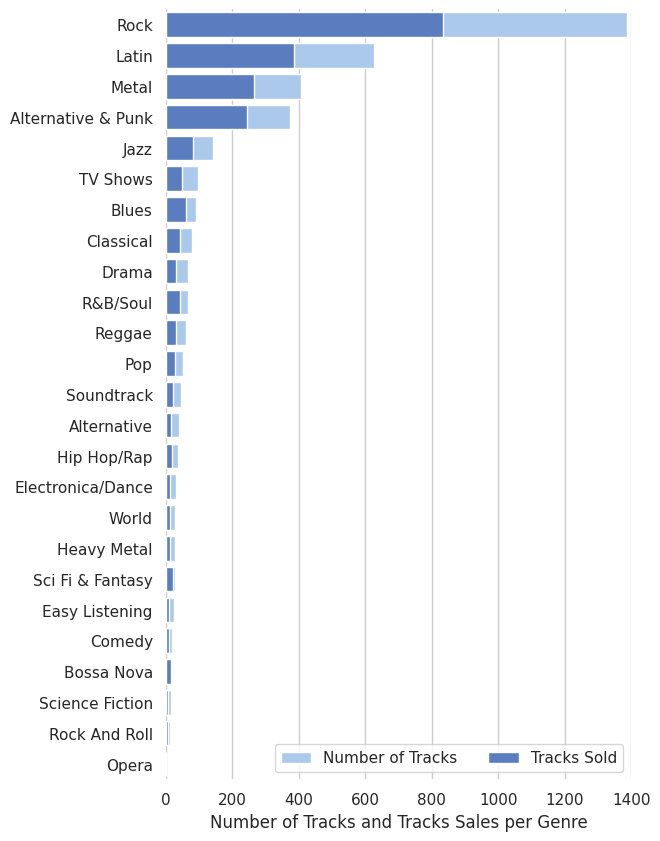

In [ ]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 10))

invoices = invoice4.sort_values("Number_of_Tracks", ascending=False)

sns.set_color_codes("pastel")
sns.barplot(x="Number_of_Tracks", y="Genre", data=invoices,
            label="Number of Tracks", color="b")

sns.set_color_codes("muted")
sns.barplot(x="Tracks_Sold", y="Genre", data=invoices,
            label="Tracks Sold", color="b")

ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(xlim=(0, 1400), ylabel="",
       xlabel="Number of Tracks and Tracks Sales per Genre")
sns.despine(left=True, bottom=True)

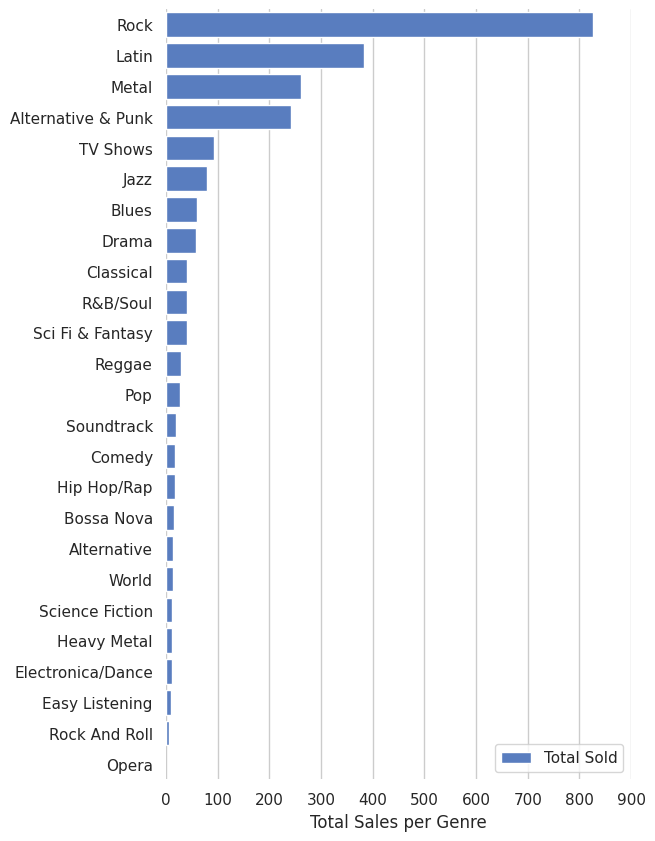

In [ ]:
f, ax2 = plt.subplots(figsize=(6, 10))

invoices = invoice4.sort_values("Total_Sold", ascending=False)

sns.set_color_codes("muted")
sns.barplot(x="Total_Sold", y="Genre", data=invoices,
            label="Total Sold", color="b")

ax2.legend(ncol=2, loc="lower right", frameon=True)
ax2.set(xlim=(0, 900), ylabel="",
       xlabel="Total Sales per Genre")
sns.despine(left=True, bottom=True)

In [ ]:
db_con.close()